In [1]:
import brainsss
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
import time
import h5py
import ants
import nibabel as nib
from scipy.ndimage import uniform_filter, gaussian_filter
import shutil
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import gc
import sys
import warnings
from scipy.ndimage import gaussian_filter1d,gaussian_filter
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz,iirnotch
import cv2
from scipy.ndimage.morphology import binary_erosion
from scipy.ndimage.morphology import binary_dilation
from scipy.ndimage import zoom
from sklearn.mixture import GaussianMixture
import scipy.stats as stats
import sklearn
import pickle
import itertools
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import pandas as pd
from skimage import measure
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.ndimage.morphology import binary_erosion, binary_dilation
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
import csv
from functools import reduce
from sklearn.decomposition import PCA

In [2]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [3]:
fly_num=['226','227','228','234','239','240','241','242','249','250']
fly_num='208'
func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly_num}/'
home_path = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/'
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')
# Suppress RuntimeWarning
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [4]:
###########################
### PREP VISUAL STIMULI ###
###########################

vision_path = os.path.join(func_path,'func_0', 'visual')

### Load Photodiode ###
t, ft_triggers, pd1, pd2 = brainsss.load_photodiode(vision_path)
stimulus_start_times = brainsss.extract_stim_times_from_pd(pd2, t)

# *100 puts in units of 10ms, which will match fictrac
st_10ms = [int(stimulus_start_times[i]*100) for i in range(len(stimulus_start_times))]

# get 1ms version to match neural timestamps
st_ms= [i*10 for i in st_10ms]
starts_loom = st_10ms

loading photodiode data... done


In [5]:
####################
### Prep Fictrac ###
####################

fictrac_path = os.path.join(func_path, 'func_0', 'fictrac')
fictrac_raw = brainsss.load_fictrac(fictrac_path)

fps = 100
resolution = 10 #desired resolution in ms
expt_len = fictrac_raw.shape[0]/fps*1000
behaviors = ['dRotLabY', 'dRotLabZ', 'dRotLabX', 'speed']
fictrac = {}
for behavior in behaviors:
    if behavior == 'dRotLabY': short = 'Y'
    elif behavior == 'dRotLabZ': short = 'Z'
    elif behavior == 'dRotLabX': short = 'X'
    fictrac[short] = brainsss.smooth_and_interp_fictrac(fictrac_raw, fps, resolution, expt_len, behavior)
fictrac_timestamps = np.arange(0,expt_len,resolution)

In [6]:
rainbow_color=np.asarray(['#FFFFFF','#EF476F', '#F78C6B', '#FFD166', '#06D6A0','#118AB2','#6A4C93','#6d0d25'])[::-1] #,  '#6d0d25'
cmap_rainbow = matplotlib.colors.LinearSegmentedColormap.from_list('cmap', rainbow_color)

In [7]:
# fig,ax=plt.subplots(figsize=(10,10))
# norm = colors.LogNorm()
# plt.hist2d(fictrac['Y'],fictrac['Z'],bins=500,cmap=cmap_rainbow,norm=norm, rasterized=True);
# ax.set_ylim(-400,400)
# ax.set_xlim(-10,10)
# # ax.set_ylabel('Rotation, deg/sec')
# # ax.set_xlabel('Forward, mm/sec')
# ax.set_xticks([])
# ax.set_yticks([])
# ax.axhline(0, linewidth=2, linestyle='--', color='k')
# ax.axvline(0, linewidth=2, linestyle='--', color='k')
# ax.spines['top'].set_visible(False);
# ax.spines['right'].set_visible(False);
# # cbar = plt.colorbar()
# # cbar.ax.tick_params(labelsize=30)
# # plt.savefig(os.path.join(save_dir,f'{fly_num}_2d_hist.png'), dpi=300, bbox_inches='tight');
# # plt.savefig(os.path.join(save_dir,f'{fly_num}_2d_hist.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [8]:
small_starts_loom= [x * 30 / 180000 for x in starts_loom]

In [9]:
# fig,ax=plt.subplots(figsize=(30,10))
# time_min = np.linspace(0, 30, len(fictrac['Y']))
# ax.plot(time_min,fictrac['Y'],color='k', rasterized=True)
# ax.set_ylim(-15,15)
# end=175000* 30 / 180000
# ax.set_xlim(0,end)
# ax.set_xticklabels([])
# ax.set_yticks([])
# # ax.tick_params(axis='x', labelsize=20) 
# ax.spines['left'].set_visible(False);
# ax.spines['right'].set_visible(False);
# ax.tick_params(axis='x', length=10, width=2)
# for i in range(len(small_starts_loom)):
#     ax.axvline(small_starts_loom[i], color='#B8860B',rasterized=True)
# plt.savefig(os.path.join(save_dir,f'{fly_num}_trace_total.png'), dpi=300, bbox_inches='tight');
# plt.savefig(os.path.join(save_dir,f'{fly_num}_trace_total.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True)

In [10]:
fixed = (brainsss.load_fda_meanbrain()).numpy()
# masked = np.full_like(data, np.nan)
# mask = fixed_np > 0.1

In [11]:
folder_name='final_movie'
if os.path.exists(os.path.join(save_dir,folder_name)):
    movie_dir=os.path.join(save_dir,folder_name)
else:
    os.mkdir(os.path.join(save_dir,folder_name))
    movie_dir=os.path.join(save_dir,folder_name)

In [12]:
# fly=208
# func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly}/'
# ts_path = os.path.join(func_path, 'warp', 'timestamps_warp.h5')
# warp_path = os.path.join(func_path,'warp/functional_channel_2_moco_warp.h5')
# with h5py.File(warp_path, 'r') as hf, h5py.File(ts_path, 'r') as tf:
# #         for i in range(3384):
#     data = hf['data']
#     dims = np.shape(data)
#     print('data',dims)
# #     masked=np.where(fixed>0.1,data, np.nan)
# #     fig,ax=plt.subplots(figsize=(10,10));
# #     ax.imshow(masked[:,:,27].T, cmap='bone');
# #     ax.axis('off');
#     ts = tf['data']
#     dims_t = np.shape(ts)
#     print('ts',dims_t )

In [13]:
# %%time
# with h5py.File(ts_path, 'r') as tf:
#     ts = tf['data'][:]
    

In [14]:
# masked_ts=np.where(fixed[...,None]>0.1,ts, np.nan)

In [15]:
# # for j in range(5,11):
# loom_tm = starts_loom[0]
# np.isin(masked_ts,loom_tm).any()
# #     t_looms=[]
# # for i in range(700):
# #     if (masked_ts[...,i]==loom_tm).any():
# #         print(i)
# #             t_looms.append(i)
# #             break

In [16]:
reds=np.asarray(['#000000','#FF0000'])
reds_spect = matplotlib.colors.LinearSegmentedColormap.from_list(
    'reds', reds)

CPU times: user 240 ms, sys: 8.49 s, total: 8.73 s
Wall time: 3min 52s


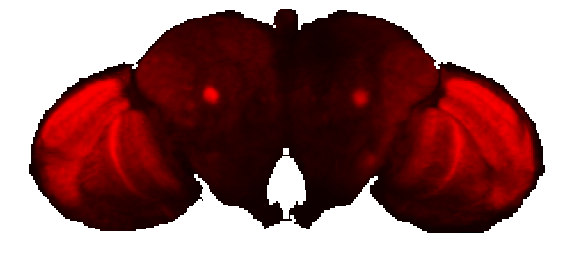

In [17]:
%%time
# fly_num=['226','227','228','234','239','240','241','242','249','250']
# for fly in fly_num:
#     print(fly)
fly=208
func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/fly_{fly}/'
warp_directory = os.path.join(func_path,'warp/functional_channel_1_moco_warp.h5')
with h5py.File(warp_directory, 'r') as hf:
#         for i in np.arange(1000,1500):
        i=1191
        data = hf['data'][...,i]
        dims = np.shape(data)
#         print(f"Data shape is {dims}")
        masked=np.where(fixed>0.1,data, np.nan)
        fig,ax=plt.subplots(figsize=(10,10));
        ax.imshow(masked[:,:,27].T, cmap=reds_spect);
        ax.axis('off');
#         plt.savefig(os.path.join(movie_dir,f'{fly}_brain_{i}.png'), dpi=300, bbox_inches='tight');
#         plt.savefig(os.path.join(save_dir,f'{fly}_brain_{tp}.svg'), dpi=300, bbox_inches='tight', format="svg", transparent=True);

In [18]:
### big STA supervox
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/'
cluster_dir = os.path.join(later_dir, 'clustering')
save_dir=os.path.join(later_dir,'figs')

behaviors = ['total', 'inc', 'dec', 'flat']

n_clusters=2000

step_size=100
event='10flies_5sec'
ch_g=2
ch_r=1
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [19]:
total_path = os.path.join(later_dir, 'behave_dict_total_10flies.pkl')
print("Loading total dict")
with open(total_path, 'rb') as file:
        data = pickle.load(file)

Loading total dict


In [20]:
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))

In [21]:
data['total'].shape

(314, 146, 91, 24)

In [22]:
behave_dict_z={}
for behavior in data:
    print(behavior)
    signals_total_z=scipy.stats.zscore(data[behavior],axis=-1)#[...,14:41]
    behave_dict_z[behavior]=signals_total_z

total
inc
dec
flat


In [23]:
behaviors=np.asarray(list(data.keys()))

In [24]:
behave_dict_z['total'].shape

(314, 146, 91, 24)

In [25]:
%%time
n_clusters=2000
supervox_dict_total=brainsss.make_supervox_dict(behave_dict_z, behaviors, n_clusters,giant_cluster_labels)


total shape: (91, 2000, 24)
inc shape: (91, 2000, 24)
dec shape: (91, 2000, 24)
flat shape: (91, 2000, 24)
CPU times: user 22.3 s, sys: 64.2 ms, total: 22.3 s
Wall time: 22.3 s


# Put the Supervoxs back into anatomical space

In [26]:
%%time
full_res={}
for behave in behaviors:
    print(behave)
    supervox_brain=supervox_dict_total[behave]
#     supervox_brain=gaussian_filter(supervox_dict_total[behave], sigma=1.5)
    supervox_brain=np.moveaxis(supervox_brain,-1,-2)
#     print(np.shape(supervox_brain))
    full_res_brain=brainsss.supervoxel_to_full_res(supervox_brain,cluster_labels=giant_cluster_labels,n_clusters=n_clusters)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    full_res_brain=np.moveaxis(full_res_brain, 0,-1)
    print(np.shape(full_res_brain))
    full_res[behave]=np.asarray(full_res_brain)

total
(314, 146, 91, 24)
inc
(314, 146, 91, 24)
dec
(314, 146, 91, 24)
flat
(314, 146, 91, 24)
CPU times: user 48.8 s, sys: 1.16 s, total: 50 s
Wall time: 50 s


In [27]:
fixed = brainsss.load_fda_meanbrain()
brain=behave_dict_z['total']
# brain=full_res_total_clean
# smoothed=gaussian_filter(full_res['total'], sigma=1.5)
# masked=np.where(fixed.numpy()[...,None]>0.1, behave_dict['total'], np.nan)
masked=np.where(fixed.numpy()[...,None]>0.1,brain, np.nan)

In [28]:
color_map_color_1=np.asarray(['#780000','#C1121F','#E0898F','#F0C4C7','#FFFFFF','#D9E6EF','#B3CDDE','#669BBC', '#003049'])[::-1]
cmap_personal = matplotlib.colors.LinearSegmentedColormap.from_list(
    'cmap', color_map_color_1)

In [29]:
load_file = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/20210817_luke_mean_highres.nii"
anat_high_res = np.asarray(nib.load(load_file).get_fdata().squeeze(), dtype='float32')
anat_high_res.shape

atlas_path = "/oak/stanford/groups/trc/data/Brezovec/2P_Imaging/anat_templates/jfrc_2018_rois_improve_reorient_transformed_nearest_neighbor.nii"
atlas = np.asarray(nib.load(atlas_path).get_fdata().squeeze(), dtype='float32')
atlas = ants.from_numpy(atlas)
atlas.set_spacing((.76,.76,.76))
#atlas = ants.resample_image(atlas,(2,2,2),use_voxels=False)
atlas = ants.resample_image(atlas,(.5,.5,.5),use_voxels=False)
print(atlas.shape)
atlas = atlas.numpy()
atlas_int = atlas.astype('uint8')

(1256, 584, 363)


In [30]:
np.shape(data['total'])

(314, 146, 91, 24)

CPU times: user 9.53 s, sys: 484 ms, total: 10 s
Wall time: 9.98 s


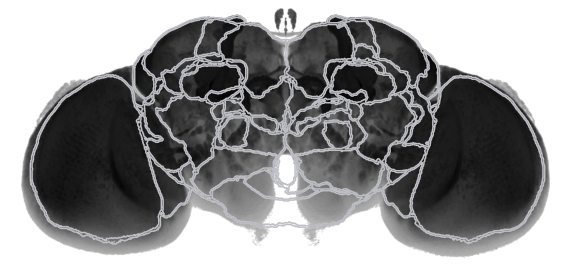

In [36]:
%%time
# for t in range(np.shape(data['total'])[-1]):
t=3

brain_t=data['total'][...,t]
# brain_t=behave_dict_z['total'][...,t]
nx,ny,nz=atlas.shape
ox,oy,oz=brain_t.shape
scale_factors = (nx/ox, ny/oy, nz/oz)
maps_voxel_high_res = zoom(brain_t, scale_factors, order=1)
masked_t=np.where(anat_high_res>0.1,maps_voxel_high_res, np.nan)

z=250
edges = cv2.Canny(np.max(atlas_int,axis=-1),1,1)
edges = binary_dilation(edges, iterations=1)
edges = scipy.ndimage.median_filter(edges,2)
#     edges_ = np.repeat(edges.astype('int')[:,:,np.newaxis],repeats=4,axis=-1) ### copy into rgba channels to make white
plt.figure(figsize=(10,10))
plt.imshow(np.max(anat_high_res, axis=-1).T,cmap='gray');
# plt.imshow(np.nanmax(masked_t, axis=-1).T,vmax=0.03,cmap=cmap_personal);
plt.contour(edges.T, levels=[0.5], colors='#BEBFC5', linewidths=1.5)
plt.axis('off');
#     plt.savefig(os.path.join(movie_dir,f'brain_fn_{t:03d}.png'), dpi=300, bbox_inches='tight')

In [130]:
def add_black_circle(input_path, output_path):
    cap = cv2.VideoCapture(input_path)
    
    # Get video properties
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    frame_num = 0
    
    # Circle parameters
    radius_s=1
    radius_e=170
    values = np.geomspace(radius_s, radius_e, 11)
    center_x = width - 180  # upper right corner
    center_y = 180
    f=0
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        # Add black circle to frames 5-15
        if 5 <= frame_num <= 15:
            print(f)
            cv2.circle(frame, (center_x, center_y), int(values[f]), (0, 0, 0), -1)
            f+=1
        
        out.write(frame)
        frame_num += 1
    
    cap.release()
    out.release()
    print(f"Processed {frame_num} frames")

In [131]:
# def add_black_oval(input_path, output_path):
#     cap = cv2.VideoCapture(input_path)
    
#     # Get video properties
#     fps = int(cap.get(cv2.CAP_PROP_FPS))
#     width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
#     height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
#     fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    
#     slow_fps = fps // 2  # Half speed
    
#     out = cv2.VideoWriter(output_path, fourcc, slow_fps, (width, height))
    
#     frame_num = 0
    
#     # Oval parameters
#     center = (width - 100, 150)  # upper right corner
#     axes = (70, 80)  # (horizontal radius, vertical radius)
#     angle = 0  # rotation angle (0 = horizontal oval)
    
#     while cap.isOpened():
#         ret, frame = cap.read()
#         if not ret:
#             break
        
#         # Add black oval to frames 5-15
#         if 5 <= frame_num <= 15:
#             cv2.ellipse(frame, center, axes, angle, 0, 360, (0, 0, 0), -1)
        
#         out.write(frame)
#         frame_num += 1
    
#     cap.release()
#     out.release()
#     print(f"Processed {frame_num} frames")


In [132]:
input_movie=os.path.join(movie_dir,'movie.mp4')
inc_movie=os.path.join(movie_dir,'movie_inc.mp4')

add_black_circle(input_movie,inc_movie)

0
1
2
3
4
5
6
7
8
9
10
Processed 24 frames
